# CSIT 598 - Assignment 1
## 02. Decision Tree Classifier

This notebook:
- Loads preprocessed MNIST artifacts
- Trains a baseline Decision Tree
- Tunes hyperparameters via grid search
- Evaluates best model on test set

In [10]:
from pathlib import Path
import json

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

from utils import evaluate_classifier, plot_confusion, RANDOM_STATE

In [11]:
project_root = Path.cwd().parent
artifact_path = project_root / 'results' / 'metrics' / 'mnist_splits.npz'

if not artifact_path.exists():
    raise FileNotFoundError(
        f"Missing artifact: {artifact_path}. Run 01_data_preprocessing.ipynb first."
    )

data = dict(__import__('numpy').load(artifact_path))
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']

print('Loaded data shapes:')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Loaded data shapes:
X_train: (50000, 784), y_train: (50000,)
X_val:   (10000, 784), y_val:   (10000,)
X_test:  (10000, 784), y_test:  (10000,)


In [12]:
# Baseline model
baseline_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_metrics = evaluate_classifier(
    baseline_model, X_train, y_train, X_val, y_val
)

print('Baseline Validation Metrics:')
print(f"Accuracy: {baseline_metrics['accuracy']:.4f}")
print(f"Precision (macro): {baseline_metrics['precision_macro']:.4f}")
print(f"Recall (macro): {baseline_metrics['recall_macro']:.4f}")
print(f"F1 (macro): {baseline_metrics['f1_macro']:.4f}")
print(f"Train time (s): {baseline_metrics['train_time_sec']:.2f}")
print(f"Pred time (s): {baseline_metrics['pred_time_sec']:.2f}")

Baseline Validation Metrics:
Accuracy: 0.8670
Precision (macro): 0.8657
Recall (macro): 0.8653
F1 (macro): 0.8654
Train time (s): 6.79
Pred time (s): 0.01


In [13]:
# Hyperparameter tuning
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print(f'Best CV accuracy: {grid.best_score_:.4f}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 2}
Best CV accuracy: 0.8651


In [14]:
# Final model retrained on train + val and evaluated on test
import numpy as np

X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

best_model = DecisionTreeClassifier(**grid.best_params_, random_state=RANDOM_STATE)
test_metrics = evaluate_classifier(
    best_model, X_train_full, y_train_full, X_test, y_test
)

print('Test Metrics:')
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision (macro): {test_metrics['precision_macro']:.4f}")
print(f"Recall (macro): {test_metrics['recall_macro']:.4f}")
print(f"F1 (macro): {test_metrics['f1_macro']:.4f}")
print(f"Train time (s): {test_metrics['train_time_sec']:.2f}")
print(f"Pred time (s): {test_metrics['pred_time_sec']:.2f}")

Test Metrics:
Accuracy: 0.8808
Precision (macro): 0.8794
Recall (macro): 0.8790
F1 (macro): 0.8791
Train time (s): 6.35
Pred time (s): 0.01


In [15]:
print(test_metrics['classification_report'])

              precision    recall  f1-score   support

           0       0.93      0.93      0.93       986
           1       0.95      0.97      0.96      1125
           2       0.87      0.85      0.86       999
           3       0.87      0.85      0.86      1020
           4       0.87      0.87      0.87       975
           5       0.84      0.82      0.83       902
           6       0.89      0.91      0.90       982
           7       0.92      0.91      0.91      1042
           8       0.85      0.83      0.84       975
           9       0.81      0.85      0.83       994

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



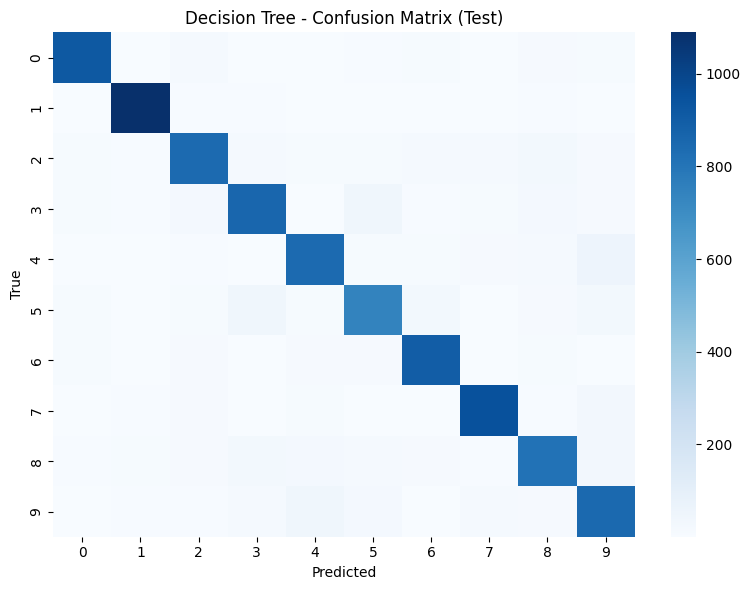

In [16]:
plot_confusion(y_test, test_metrics['y_pred'], title='Decision Tree - Confusion Matrix (Test)')

In [17]:
# Persist metrics for final comparison notebook
metrics_dir = project_root / 'results' / 'metrics'
metrics_dir.mkdir(parents=True, exist_ok=True)

to_save = {k: v for k, v in test_metrics.items() if k != 'y_pred'}
to_save['model_name'] = 'DecisionTree'
to_save['best_params'] = grid.best_params_

output_file = metrics_dir / 'decision_tree_metrics.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(to_save, f, indent=2)

print(f'Metrics saved to: {output_file}')

Metrics saved to: /Users/nrjsingh1/Library/Mobile Documents/com~apple~CloudDocs/MS_courses/CSIT_598_MachineLear/Assignments/project/results/metrics/decision_tree_metrics.json
